<a href="https://colab.research.google.com/github/Ilannahaimenis19/Data-science_Exercises/blob/main/Classificadores_1_Viol%C3%AAncia_contra_mulher.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn as sk
import kagglehub
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np

path = kagglehub.dataset_download("fahmidachowdhury/domestic-violence-against-women")

print("Path to dataset files:", path)

df_violence = pd.read_csv(f'{path}/Domestic violence.csv')

display(df_violence)

Path to dataset files: /kaggle/input/domestic-violence-against-women


,SL. No,Age,Education,Employment,Income,Marital status,Violence
0,1,30,secondary,unemployed,0,married,yes
1,2,47,tertiary,unemployed,0,married,no
2,3,24,tertiary,unemployed,0,unmarred,no
3,4,22,tertiary,unemployed,0,unmarred,no
4,5,50,primary,unemployed,0,married,yes
...,...,...,...,...,...,...,...
342,343,27,tertiary,semi employed,30000,unmarred,no
343,344,26,tertiary,employed,35000,married,no
344,345,27,primary,unemployed,0,married,yes
345,346,29,primary,unemployed,0,married,no


In [ ]:
# Remove espaços extras no nome das colunas
df_violence.columns = df_violence.columns.str.strip()

# Remover coluna de ID
df_violence = df_violence.drop(columns=['SL. No'])

# Separa features e target
X = df_violence.drop(columns=['Violence'])
y = df_violence['Violence']

# Identifica colunas categóricas (string)
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

#Cria o OneHotEncoder (compatível com versões antigas e novas do sklearn)
ohe_kwargs = dict(handle_unknown='ignore', drop='first')
try:
    # sklearn >= 1.2
    encoder = OneHotEncoder(sparse_output=False, **ohe_kwargs)
except TypeError:
    # sklearn < 1.2
    encoder = OneHotEncoder(sparse=False, **ohe_kwargs)

# 4) Ajusta e transforma apenas as categóricas
X_encoded = encoder.fit_transform(X[cat_cols])           # numpy array
encoded_col_names = encoder.get_feature_names_out(cat_cols).tolist()

# 5) Concatena com as numéricas e devolve DataFrame com nomes de colunas
X_num = X[num_cols].to_numpy()
X_final = np.hstack([X_num, X_encoded])
feature_names = num_cols + encoded_col_names
X_final_df = pd.DataFrame(X_final, columns=feature_names)

print("Shape final:", X_final_df.shape)
print("Categóricas:", cat_cols)
print("Numéricas:", num_cols)
X_final_df.head()

Shape final: (347, 9)
Categóricas: ['Education', 'Employment', 'Marital status']
Numéricas: ['Age', 'Income']


,Age,Income,Education_primary,Education_secondary,Education_tertiary,Employment_employed,Employment_semi employed,Employment_unemployed,Marital status_unmarred
0,30.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,47.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,24.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,22.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,50.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Cria o scaler
scaler = MinMaxScaler()

# Ajusta e transforma
X_scaled = scaler.fit_transform(X_final_df)

# Converte de volta para DataFrame (mantendo nomes das colunas)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_final_df.columns)

# Verificação
X_scaled_df.head()


,Age,Income,Education_primary,Education_secondary,Education_tertiary,Employment_employed,Employment_semi employed,Employment_unemployed,Marital status_unmarred
0,0.333333,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.711111,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.200000,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
3,0.155556,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
4,0.777778,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from collections import Counter
print("Antes:", Counter(y))


#Balancear com SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_final_df, y)

print("Depois (SMOTE):", Counter(y_smote))

Antes: Counter({'no': 261, 'yes': 86})
Depois (SMOTE): Counter({'yes': 261, 'no': 261})


In [ ]:
# Setup comum para todas os classificadores
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, ConfusionMatrixDisplay, classification_report, accuracy_score

# folds estratificados e métricas
skf = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "f1w": make_scorer(f1_score, average="weighted")
}

# split fixo para gerar as matrizes de confusão (mesmo para todos)
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, stratify=y_smote, random_state=42
)

# Logistic Regression

LR | Acc (média): 0.6284204345273048
LR | F1w (média): 0.6258024211937716
LR | Accuracy (holdout): 0.5904761904761905
              precision    recall  f1-score   support

          no       0.62      0.47      0.54        53
         yes       0.57      0.71      0.63        52

    accuracy                           0.59       105
   macro avg       0.60      0.59      0.59       105
weighted avg       0.60      0.59      0.58       105



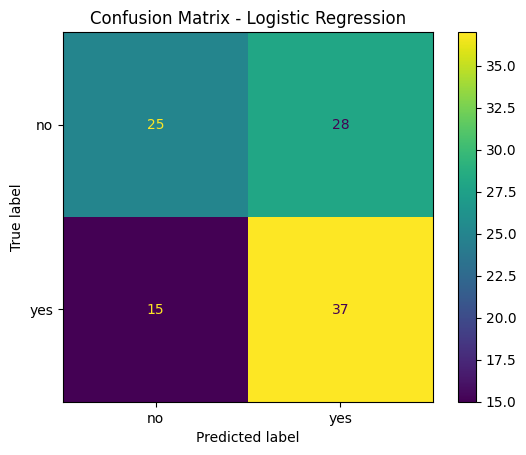

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# pipeline
lr_pipe = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# CV: accuracy + f1-weighted
cv_lr = cross_validate(lr_pipe, X_smote, y_smote, cv=skf, scoring=scoring, n_jobs=-1)
print("LR | Acc (média):", np.mean(cv_lr["test_accuracy"]))
print("LR | F1w (média):", np.mean(cv_lr["test_f1w"]))

# Holdout: matriz de confusão + relatório
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)
print("LR | Accuracy (holdout):", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# KNeighborsClassifier

KNN | Acc (média): 0.756635349383441
KNN | F1w (média): 0.7561058503043875
KNN | Accuracy (holdout): 0.7523809523809524
              precision    recall  f1-score   support

          no       0.80      0.68      0.73        53
         yes       0.72      0.83      0.77        52

    accuracy                           0.75       105
   macro avg       0.76      0.75      0.75       105
weighted avg       0.76      0.75      0.75       105



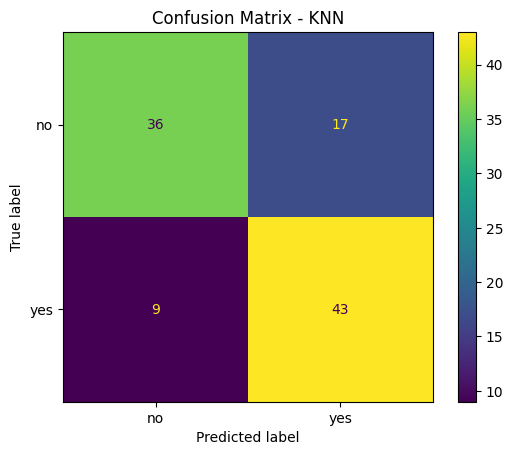

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5))
])

cv_knn = cross_validate(knn_pipe, X_smote, y_smote, cv=skf, scoring=scoring, n_jobs=-1)
print("KNN | Acc (média):", np.mean(cv_knn["test_accuracy"]))
print("KNN | F1w (média):", np.mean(cv_knn["test_f1w"]))

knn_pipe.fit(X_train, y_train)
y_pred_knn = knn_pipe.predict(X_test)
print("KNN | Accuracy (holdout):", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)
plt.title("Confusion Matrix - KNN")
plt.show()


# DecisionTreeClassifier



DT  | Acc (média): 0.7873018203170875
DT  | F1w (média): 0.7868972023687278
DT  | Accuracy (holdout): 0.7619047619047619
              precision    recall  f1-score   support

          no       0.77      0.75      0.76        53
         yes       0.75      0.77      0.76        52

    accuracy                           0.76       105
   macro avg       0.76      0.76      0.76       105
weighted avg       0.76      0.76      0.76       105



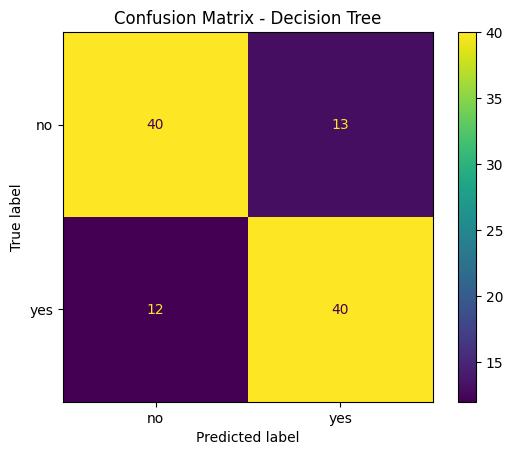

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

dt_pipe = Pipeline([
    ("clf", DecisionTreeClassifier(random_state=42))
])

cv_dt = cross_validate(dt_pipe, X_smote, y_smote, cv=skf, scoring=scoring, n_jobs=-1)
print("DT  | Acc (média):", np.mean(cv_dt["test_accuracy"]))
print("DT  | F1w (média):", np.mean(cv_dt["test_f1w"]))

dt_pipe.fit(X_train, y_train)
y_pred_dt = dt_pipe.predict(X_test)
print("DT  | Accuracy (holdout):", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Confusion Matrix - Decision Tree")
plt.show()